In [ ]:
# !pip install pandas
# !pip install statsmodels
# !pip install pyreadstat

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pyreadstat
from sklearn import linear_model
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Data Preparation for Question 0

In [ ]:
# load data
df = pd.read_csv('/content/Team Assignment 1 Data 2026.csv', sep=';')
df.head()

,Post_ID,Caption_Length,ZCaption_Length,Topic_Prod_Features,Topic_Prod_Features_Positive,Topic_Prod_Features_Negative,Topic_Promo_Deal,Topic_Promo_Deal_Positive,Topic_Promo_Deal_Negative,Topic_Lifestyle_Values,...,Platform,Post_Type,Influencer_Gender,Influencer_Age,Influencer_Tier,Follower_Count_K,Caption_Sentiment,Engagement_Rate,Click_Through,Comment_Count
0,1,26,-0.6817,0,0,0,1,1,0,0,...,0,1,1,24.2,1,669.4,5,7.90,1,42
1,2,29,-0.5492,0,0,0,0,0,0,0,...,1,1,0,26.0,0,44.8,5,9.55,0,48
2,3,25,-0.7258,0,0,0,0,0,0,0,...,1,1,0,18.6,0,45.3,4,10.57,0,95
3,4,17,-10.7920,1,1,0,0,0,0,0,...,1,1,0,23.0,0,45.9,2,9.14,1,28
4,5,40,-0.0632,0,0,0,0,0,0,0,...,0,1,1,31.8,0,19.1,4,6.63,0,10


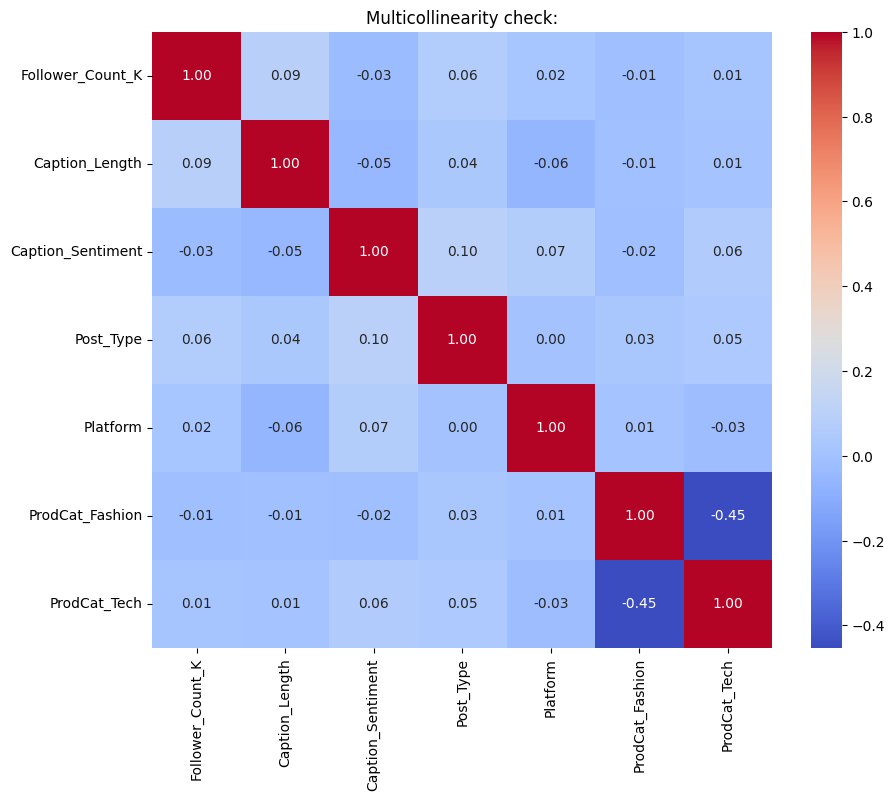

Data preparation complete. Ready for Question 1!


In [ ]:
# create dummy variables for Product_Category: drop 'Beauty & Skincare'
df_final = pd.get_dummies(df, columns=['Product_Category'], drop_first=False)
df_final = df_final.rename(columns={'Product_Category_1': 'ProdCat_Fashion', 'Product_Category_2': 'ProdCat_Tech'})
df_final = df_final.drop('Product_Category_0', axis=1) # drop Category 1: Beauty

# check multicollinearity: look at main numeric features
features_to_check = [
    'Follower_Count_K',
    'Caption_Length',
    'Caption_Sentiment',
    'Post_Type',
    'Platform',
    'ProdCat_Fashion',
    'ProdCat_Tech']
corr_matrix = df_final[features_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Multicollinearity check:")
plt.show()

print("Data preparation complete. Ready for Question 1!")



# Linear Regression Model for Question 1

In [ ]:
selected_features = ['Topic_Promo_Deal', 'Topic_CTA', 'Platform', 'Post_Type', 'Influencer_Tier', 'Caption_Sentiment', 'ProdCat_Fashion', 'ProdCat_Tech']
X1 = df_final[selected_features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
Y1 = pd.to_numeric(df_final['Engagement_Rate'], errors='coerce').fillna(0).astype(float)
print("\nColumn Types check:")
print(df_final[selected_features].dtypes)


Column Types check:
Topic_Promo_Deal     int64
Topic_CTA            int64
Platform             int64
Post_Type            int64
Influencer_Tier      int64
Caption_Sentiment    int64
ProdCat_Fashion       bool
ProdCat_Tech          bool
dtype: object


In [ ]:
X1 = sm.add_constant(X1)
model = sm.OLS(Y1, X1).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     107.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          6.35e-110
Time:                        16:02:24   Log-Likelihood:                -1123.7
No. Observations:                 600   AIC:                             2265.
Df Residuals:                     591   BIC:                             2305.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.1688      0.27

In [ ]:
# define features (from heatmap)
features = [
'Follower_Count_K',
'Caption_Length',
'Caption_Sentiment',
'Post_Type',
'Platform',
'ProdCat_Fashion',
'ProdCat_Tech'
]

X = df_final[features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
y = pd.to_numeric(df_final['Engagement_Rate'], errors='coerce').fillna(0).astype(float)

X = sm.add_constant(X) # add constant
model_engagement = sm.OLS(y, X).fit() # fit model
print(model_engagement.summary())

                            OLS Regression Results                            
Dep. Variable:        Engagement_Rate   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     115.5
Date:                Mon, 06 Apr 2026   Prob (F-statistic):          2.27e-106
Time:                        16:02:26   Log-Likelihood:                -1134.6
No. Observations:                 600   AIC:                             2285.
Df Residuals:                     592   BIC:                             2320.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 7.0151      0.29

# Logistic Regression Model for Question 2

In [ ]:
selected_features = ['Topic_Promo_Deal', 'Topic_CTA', 'Platform', 'Post_Type', 'Influencer_Tier', 'Caption_Sentiment', 'ProdCat_Fashion', 'ProdCat_Tech']
X2 = df_final[selected_features].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
Y2 = pd.to_numeric(df_final['Click_Through'], errors='coerce').fillna(0).astype(float)

In [ ]:
X2 = sm.add_constant(X2)
logit_mod = sm.Logit(Y2, X2)
logit_res = logit_mod.fit()
print("Odds Ratios:")
print(np.exp(logit_res.params))

Optimization terminated successfully.
         Current function value: 0.641596
         Iterations 5
Odds Ratios:
const                0.190043
Topic_Promo_Deal     1.617418
Topic_CTA            3.092715
Platform             1.193682
Post_Type            1.528705
Influencer_Tier      1.270814
Caption_Sentiment    1.124671
ProdCat_Fashion      0.866505
ProdCat_Tech         1.094853
dtype: float64


# Poisson Regression Model for Question 3

In [ ]:
# define variables
independent_vars = ['Topic_Promo_Deal', 'Topic_CTA', 'Platform', 'Post_Type', 'Influencer_Tier', 'Caption_Sentiment', 'ProdCat_Fashion', 'ProdCat_Tech']
dependent_var = 'Comment_Count'

In [ ]:
# data prep
X3 = df_final[independent_vars].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
Y3 = pd.to_numeric(df_final[dependent_var], errors='coerce').fillna(0).astype(float)
X3 = sm.add_constant(X3)

In [ ]:
# Poisson Regression Model
poisson_model = sm.GLM(Y3, X3, family=sm.families.Poisson())
poisson_results = poisson_model.fit()

# Negative Binomial Regression Model
nb_model = sm.GLM(Y3, X3, family=sm.families.NegativeBinomial())
nb_results = nb_model.fit()

print("Poisson Regression Results:")
print(poisson_results.summary())
print("Negative Binomial Regression Results:")
print(nb_results.summary())

Poisson Regression Results:
                 Generalized Linear Model Regression Results                  
Dep. Variable:          Comment_Count   No. Observations:                  600
Model:                            GLM   Df Residuals:                      591
Model Family:                 Poisson   Df Model:                            8
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -5609.9
Date:                Mon, 06 Apr 2026   Deviance:                       7997.1
Time:                        16:03:10   Pearson chi2:                 8.72e+03
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const     

# Multivariate Logit for Question 4

In [ ]:
# ceate interaction term: CTA multiplied by Platform: tests if the 'Power of the CTA' changes based on the Platform
df_final['CTA_x_Platform'] = df_final['Topic_CTA'] * df_final['Platform']

# define features (including new interaction)
features_q4 = ['Topic_Promo_Deal', 'Topic_CTA', 'Platform', 'Post_Type', 'Influencer_Tier', 'Caption_Sentiment', 'ProdCat_Fashion', 'ProdCat_Tech', 'CTA_x_Platform']
X4 = df_final[features_q4].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
Y4 = pd.to_numeric(df_final['Click_Through'], errors='coerce').fillna(0).astype(float)
X4 = sm.add_constant(X4)

In [ ]:
# fit Logit Model
logit_interaction = sm.Logit(Y4, X4).fit()

print(logit_interaction.summary())
print("Interaction Odds Ratios:")
print(np.exp(logit_interaction.params))

Optimization terminated successfully.
         Current function value: 0.640695
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:          Click_Through   No. Observations:                  600
Model:                          Logit   Df Residuals:                      590
Method:                           MLE   Df Model:                            9
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.07564
Time:                        16:19:37   Log-Likelihood:                -384.42
converged:                       True   LL-Null:                       -415.87
Covariance Type:            nonrobust   LLR p-value:                 3.662e-10
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.7892      0.398     -4.496      0.000      -2.569      -1.009
Topic_Pr